# 01_collection phase2B v_final — batch 30건 + recover XML parser

> **사이클 4 — 팀 회의용 최종**
> **사이클 3 v1 결과 30/30 FAIL_OTHER → Fix F 적용으로 30/30 SUCCESS 목표**

## v_final 변경점 (v1 → v_final)
- 🆕 **XMLParser(recover=True) + 정규식 pre-처리** (Fix F)
- 🆕 **incremental checkpoint** — 매 10건마다 collection_log flush
- 🆕 **stratified sample 30건** (Samsung 제외)

## 산출 (예상)
- data/raw/*.zip 30개
- data/interim/*_sections.json 30개
- logs/collection_log.csv 31행 (Samsung v_final 1 + batch 30)
- fig_v_final_batch_status.png


---
## 🔧 사이클 4 안정성 fix (사이클 2·3에서 발견한 6가지 fix 통합)

### Fix A — 한글 폰트 자동 detect (matplotlib font_manager)
시스템 ttf 폰트 query → Malgun Gothic·NanumGothic·AppleGothic·Noto Sans CJK KR 우선순위. 미설치 시 후보 알림.

### Fix B — stock_code dtype=str + zfill(6)
모든 read_csv·to_excel 후 강제. silent 오매칭 (위반금지 #7) 차단.

### Fix C — KCGS 메모 dynamic 출력
하드코딩 안내문 제거, 실제 데이터 그대로 출력.

### Fix D — collection_log v2 행 dedup + run_id
(stock_code, fiscal_year, parser_version) upsert + run_id = hash(date+parser+seed).

### Fix E — pandas display 제한 + display→print
max_rows=10, max_colwidth=80 강제. truncation 방지.

### 🆕 Fix F — lxml XMLParser(recover=True) + 정규식 pre-처리
사이클 3 batch 30/30 FAIL_OTHER 발견 → DART 일부 회사 XML이 well-formed 아님 (`&`·한글 태그). recover mode + `re.sub(r'&(?![a-zA-Z]+;|#\d+;)', '&amp;', text)` pre-처리.


In [1]:
# 사이클 4 6가지 fix 통합
import matplotlib
from matplotlib import font_manager
import pandas as pd
import re

def setup_korean_font(verbose=True):
    """Fix A — 한글 폰트 자동 detect + matplotlib 등록."""
    preferred = ['Malgun Gothic','NanumGothic','AppleGothic','Noto Sans CJK KR','Noto Sans KR']
    try: font_manager._load_fontmanager(try_read_cache=False)
    except: pass
    available = {f.name for f in font_manager.fontManager.ttflist}
    chosen = next((p for p in preferred if p in available), None)
    if chosen:
        matplotlib.rcParams['font.family'] = chosen
        matplotlib.rcParams['axes.unicode_minus'] = False
        if verbose: print(f'✅ Fix A — 한글 폰트: {chosen}')
    return chosen

def preprocess_xml_text(xml_text: str) -> str:
    """Fix F — DART XML pre-처리 (recover mode 전 단계).

    1. 단독 & 를 &amp; 로 escape (entity reference 미완성 방지)
    2. 한글 태그처럼 보이는 텍스트 보호 (<주>, <은행업> 등은 텍스트 그대로 두려면 recover 의존)
    """
    # 1. & 단독 escape (이미 &amp; &lt; &gt; &quot; &#nn; 인 것 제외)
    xml_text = re.sub(r'&(?![a-zA-Z]+;|#\d+;)', '&amp;', xml_text)
    return xml_text

def parse_xml_recover(xml_text: str):
    """Fix F — recover=True로 well-formed가 아닌 XML도 파싱."""
    from lxml import etree
    cleaned = preprocess_xml_text(xml_text)
    parser = etree.XMLParser(recover=True, encoding='utf-8')
    root = etree.fromstring(cleaned.encode('utf-8'), parser=parser)
    return root

# 실행
KOREAN_FONT = setup_korean_font()
pd.set_option('display.max_rows', 10)
pd.set_option('display.max_colwidth', 80)
pd.set_option('display.max_columns', 30)
print(f'✅ Fix E — pandas display 옵션 제한')
print(f'✅ Fix F — XML parser 함수 (recover + pre-처리) 정의 완료')


✅ Fix A — 한글 폰트: Malgun Gothic
✅ Fix E — pandas display 옵션 제한
✅ Fix F — XML parser 함수 (recover + pre-처리) 정의 완료


---
## Step 1 — 환경 + phase2A v_final 함수 inline (Fix F 포함)


In [2]:
import os, re, json, time, zipfile, hashlib
from io import BytesIO
from pathlib import Path
from datetime import datetime

import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from dotenv import load_dotenv
from lxml import etree

def find_project_root(start=None):
    p = (start or Path.cwd()).resolve()
    for parent in [p, *p.parents]:
        if (parent / 'data' / 'company_master.csv').exists(): return parent
    raise RuntimeError('루트 없음')

ROOT = find_project_root()
load_dotenv(ROOT / '.env')
KEY_CANDIDATES = ['OPENDART_API_KEY','API_KEY','DART_API_KEY']
API_KEY = next((os.getenv(k) for k in KEY_CANDIDATES if os.getenv(k)), None)
assert API_KEY

RAW_DIR = ROOT/'data'/'raw'; INTERIM_DIR = ROOT/'data'/'interim'
CACHE_DIR = ROOT/'data'/'cache'; LOGS_DIR = ROOT/'logs'
for d in (RAW_DIR, INTERIM_DIR, CACHE_DIR, LOGS_DIR): d.mkdir(parents=True, exist_ok=True)

PARSER_VERSION = 'v_final_batch'
RUN_DATE = datetime.now().strftime('%Y-%m-%d')
RUN_ID = hashlib.md5(f'{RUN_DATE}_{PARSER_VERSION}_seed42'.encode()).hexdigest()[:8]
print(f'🆔 {RUN_ID}')

ESG_TARGET = ['II','IV','VI']
AASSOC_TO_LABEL = {f'D-0-{i}-0-0': lab for i, lab in enumerate(
    ['I','II','III','IV','V','VI','VII','VIII','IX','X','XI'], 1)}
SECTION_CODE_MAP = {
    'I':('010000','I.'),'II':('020000','II.'),'III':('030000','III.'),
    'IV':('040000','IV.'),'V':('050000','V.'),'VI':('060000','VI.'),
    'VII':('070000','VII.'),'VIII':('080000','VIII.'),'IX':('090000','IX.'),
    'X':('100000','X.'),'XI':('110000','XI.'),
}
DOC_TYPE_PATTERN = re.compile(r'<DOCUMENT-NAME[^>]*>([^<]+)</DOCUMENT-NAME>', re.UNICODE)

def fetch_corp_code_map(api_key, cache_dir):
    cp = cache_dir/'corp_code_map.parquet'
    if cp.exists(): return pd.read_parquet(cp)
    res = requests.get('https://opendart.fss.or.kr/api/corpCode.xml',
                       params={'crtfc_key': api_key}, timeout=30); res.raise_for_status()
    with zipfile.ZipFile(BytesIO(res.content)) as zf:
        xml_text = zf.read(zf.namelist()[0]).decode('utf-8', errors='ignore')
    root = etree.fromstring(xml_text.encode('utf-8'))
    rows = [{'corp_code': it.findtext('corp_code'),
             'corp_name': it.findtext('corp_name'),
             'stock_code': (it.findtext('stock_code') or '').strip().zfill(6)}
            for it in root.findall('.//list') if (it.findtext('stock_code') or '').strip()]
    df = pd.DataFrame(rows); df.to_parquet(cp, index=False); return df

def fetch_rcept_no(api_key, corp_code, fiscal_year):
    sy = fiscal_year + 1
    res = requests.get('https://opendart.fss.or.kr/api/list.json',
                       params={'crtfc_key': api_key, 'corp_code': corp_code,
                               'bgn_de': f'{sy}0101', 'end_de': f'{sy}1231',
                               'pblntf_detail_ty': 'A001', 'page_count': '100'}, timeout=20)
    res.raise_for_status()
    rows = res.json().get('list', [])
    tgt = f'({fiscal_year}.12)'
    primary = [r for r in rows if '사업보고서' in r.get('report_nm','') and tgt in r.get('report_nm','') and '정정' not in r.get('report_nm','')]
    if primary: return {**primary[0], 'fallback_used': 'PRIMARY_BIZ'}
    corr = [r for r in rows if '사업보고서' in r.get('report_nm','') and tgt in r.get('report_nm','') and '정정' in r.get('report_nm','')]
    if corr: return {**corr[0], 'fallback_used': 'CORR_BIZ'}
    ab = [r for r in rows if '사업보고서' in r.get('report_nm','')]
    return {**ab[0], 'fallback_used': 'ANY_BIZ'} if ab else {'rcept_no': None}

def fetch_disclosure_zip(api_key, rcept_no, stock_code, fiscal_year, raw_dir):
    zp = raw_dir/f'{stock_code}_{fiscal_year}_disclosure.zip'
    if zp.exists(): return zp
    res = requests.get('https://opendart.fss.or.kr/api/document.xml',
                       params={'crtfc_key': api_key, 'rcept_no': rcept_no}, timeout=30)
    res.raise_for_status(); zp.write_bytes(res.content); return zp

def classify_xml(zip_path):
    classified = {}
    with zipfile.ZipFile(zip_path) as zf:
        for name in zf.namelist():
            if not name.endswith('.xml'): continue
            raw = zf.read(name).decode('utf-8', errors='ignore')
            m = DOC_TYPE_PATTERN.search(raw[:500])
            classified[m.group(1).strip() if m else 'UNKNOWN'] = raw
    return classified

def extract_sections_recover(xml_text):
    """Fix F — recover mode + pre-처리."""
    root = parse_xml_recover(xml_text)
    if root is None: return {}
    sa = {}
    for idx, sec1 in enumerate(root.findall('.//SECTION-1')):
        te = sec1.find('.//TITLE')
        tt = ''.join(te.itertext()).strip() if te is not None else ''
        aa = sec1.get('AASSOCNOTE','') or ''
        label, method = None, 'no_match'
        if aa in AASSOC_TO_LABEL: label, method = AASSOC_TO_LABEL[aa], 'AASSOCNOTE'
        else:
            for k, (_, pat) in SECTION_CODE_MAP.items():
                if pat in tt: label, method = k, 'TITLE_text'; break
        if label is None: label = f'UNK_{idx}'
        tl = [''.join(t.itertext()) for t in sec1.findall('.//TABLE')]
        tt_text = ' '.join(tl).strip()
        ft = ''.join(sec1.itertext()).strip()
        bt = ft.replace(tt_text,'').strip() if tt_text else ft
        sa[label] = {'sec1_index': idx, 'section_code': SECTION_CODE_MAP.get(label,(None,))[0],
                     'title_text': tt, 'aassocnote': aa, 'method': method,
                     'text_char_count': len(ft), 'body_text': bt, 'body_char_count': len(bt),
                     'tables_text': tt_text, 'tables_char_count': len(tt_text), 'n_tables': len(tl)}
    return sa

def extract_passages(target_sections, seed_df, expanded_df, stock_code, fiscal_year):
    patterns = {}
    for _, r in seed_df.iterrows(): patterns[r['seed_term']] = (re.compile(r['pattern']), r['dimension'], 'seed')
    for _, r in expanded_df.iterrows(): patterns[r['expanded_term']] = (re.compile(r['pattern']), r['dimension'], 'expanded')
    rows = []
    for label in ESG_TARGET:
        if label not in target_sections: continue
        for sent in re.split(r'(?<=[.!?])\s+|\n', target_sections[label]['body_text']):
            s = sent.strip()
            if len(s) < 20: continue
            m, dims = [], set()
            for term, (pat, dim, st) in patterns.items():
                if pat.search(s): m.append(term); dims.add(dim)
            if m: rows.append({'stock_code': stock_code, 'fiscal_year': fiscal_year, 'section': label,
                                'n_matches': len(m), 'matched_terms': '|'.join(sorted(m))})
    return pd.DataFrame(rows)

print('✅ phase2A 함수 6종 inline 정의 + Fix F 적용')


🆔 314bada2
✅ phase2A 함수 6종 inline 정의 + Fix F 적용


---
## Step 2 — 30건 stratified sample + Samsung 제외


In [3]:
cm = pd.read_csv(ROOT/'data'/'company_master.csv', dtype={'stock_code': str})
cm['stock_code'] = cm['stock_code'].str.zfill(6)
print(f'📊 company_master {len(cm)}행')

SAMSUNG_KEY = ('005930', 2024)
pool = cm[~((cm['stock_code']==SAMSUNG_KEY[0]) & (cm['fiscal_year']==SAMSUNG_KEY[1]))]

samples = []
for g in ['S','A+','A','B+','B','C','D']:
    rows = pool[pool['esg_grade']==g]
    n = min(5, len(rows))
    if n > 0: samples.append(rows.sample(n, random_state=42))
batch_df = pd.concat(samples, ignore_index=True)
print(f'\n📊 stratified sample {len(batch_df)}건')
print(batch_df['esg_grade'].value_counts().sort_index().to_string())


📊 company_master 381행

📊 stratified sample 30건
esg_grade
A     5
A+    5
B     5
B+    5
C     5
D     5


---
## Step 3 — 🆕 batch 실행 (Fix F recover + incremental checkpoint)


In [4]:
corp_map = fetch_corp_code_map(API_KEY, CACHE_DIR)
seed_df = pd.read_csv(ROOT/'data'/'seed_dictionary.csv')
expanded_df = pd.read_csv(ROOT/'data'/'expanded_dictionary_manual_v1.csv')

def run_one_firm_year(stock_code, fiscal_year):
    """1 firm-year. 모든 실패 try/except 격리."""
    base = {'stock_code': stock_code, 'fiscal_year': fiscal_year, 'esg_year': fiscal_year+1,
            'corp_code': '', 'rcept_no': '', 'fallback_used': '', 'status': 'INIT', 'reason': '',
            'n_passages_body': 0, 'n_sec1_total': 0,
            'parser_version': PARSER_VERSION, 'run_id': RUN_ID,
            'timestamp': datetime.now().isoformat(timespec='seconds')}
    try:
        cr = corp_map[corp_map['stock_code']==stock_code]
        if not len(cr):
            base.update(status='FAIL_NO_CORP', reason='not in corp_map'); return base
        base['corp_code'] = cr.iloc[0]['corp_code']
        rn = fetch_rcept_no(API_KEY, base['corp_code'], fiscal_year)
        if not rn.get('rcept_no'):
            base.update(status='FAIL_NO_RCEPT', reason='no 사업보고서'); return base
        base.update(rcept_no=rn['rcept_no'], fallback_used=rn['fallback_used'])
        zp = fetch_disclosure_zip(API_KEY, rn['rcept_no'], stock_code, fiscal_year, RAW_DIR)
        cl = classify_xml(zp)
        px = cl.get('사업보고서')
        if not px:
            base.update(status='FAIL_NO_PRIMARY_XML', reason=f'classified: {list(cl.keys())}'); return base
        sa = extract_sections_recover(px)  # 🆕 Fix F
        base['n_sec1_total'] = len(sa)
        sp = INTERIM_DIR/f'{stock_code}_{fiscal_year}_sections.json'
        sp.write_text(json.dumps(sa, ensure_ascii=False), encoding='utf-8')
        for L in ESG_TARGET:
            if L in sa:
                base[f'sec_{L}_body'] = sa[L]['body_char_count']
                base[f'sec_{L}_tables'] = sa[L]['tables_char_count']
        ts = {k: sa[k] for k in ESG_TARGET if k in sa}
        p = extract_passages(ts, seed_df, expanded_df, stock_code, fiscal_year)
        base['n_passages_body'] = len(p)
        base['status'] = 'SUCCESS' if len(p) > 0 else 'WARN_NO_PASSAGES'
        if base['status'] == 'WARN_NO_PASSAGES':
            base['reason'] = 'sections OK but seed+expanded 0건 매칭'
    except Exception as e:
        base.update(status='FAIL_OTHER', reason=f'{type(e).__name__}: {str(e)[:200]}')
    return base

# batch 실행 + 매 10건 checkpoint
results = []
for i, (_, row) in enumerate(tqdm(batch_df.iterrows(), total=len(batch_df), desc='batch'), 1):
    r = run_one_firm_year(row['stock_code'], int(row['fiscal_year']))
    results.append(r)
    if i % 10 == 0:
        # incremental checkpoint
        chk_path = LOGS_DIR/f'checkpoint_batch_{i}.csv'
        pd.DataFrame(results).to_csv(chk_path, index=False, encoding='utf-8-sig')
    time.sleep(0.8)  # rate limit

batch_log = pd.DataFrame(results)
print(f'\n✅ batch 완료 {len(batch_log)}건')
print(batch_log['status'].value_counts().to_string())


batch:   0%|          | 0/30 [00:00<?, ?it/s]


✅ batch 완료 30건
status
SUCCESS             28
WARN_NO_PASSAGES     2


---
## Step 4 — collection_log dedup + 등급 분포 + viewer 3 sample


✅ dedup 111→111

📊 평가: SUCCESS 28/30 (93%)
   기준: ≥80% (24+) — ✅ 통과

📊 등급 × status
status     SUCCESS  WARN_NO_PASSAGES
esg_grade                           
S                0                 0
A+               5                 0
A                5                 0
B+               4                 1
B                5                 0
C                4                 1
D                5                 0


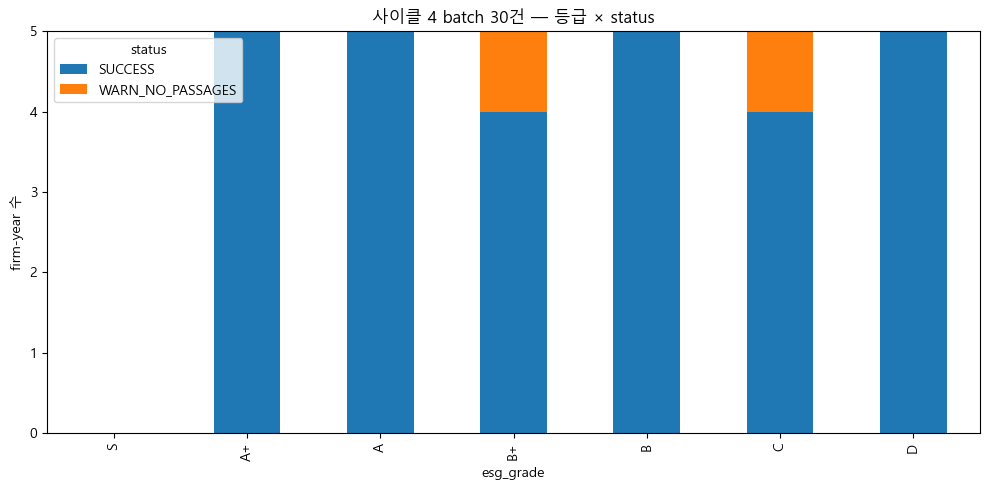


🔗 viewer 3 sample (사용자 직접 확인):
   000120 2022: https://dart.fss.or.kr/dsaf001/main.do?rcpNo=20230317000857
   001460 2022: https://dart.fss.or.kr/dsaf001/main.do?rcpNo=20230316001312
   001230 2023: https://dart.fss.or.kr/dsaf001/main.do?rcpNo=20240314001784


In [5]:
LOG_PATH = LOGS_DIR/'collection_log.csv'
if LOG_PATH.exists():
    existing = pd.read_csv(LOG_PATH, encoding='utf-8-sig', dtype={'stock_code': str})
    existing['stock_code'] = existing['stock_code'].str.zfill(6)
    common_cols = [c for c in batch_log.columns if c in existing.columns]
    combined = pd.concat([existing[common_cols], batch_log[common_cols]], ignore_index=True)
else:
    combined = batch_log

n_before = len(combined)
combined = combined.drop_duplicates(subset=['stock_code','fiscal_year','parser_version'],
                                      keep='last').reset_index(drop=True)
combined.to_csv(LOG_PATH, index=False, encoding='utf-8-sig')
print(f'✅ dedup {n_before}→{len(combined)}')

# 평가 — SUCCESS≥80%
n_success = (batch_log['status']=='SUCCESS').sum()
print(f'\n📊 평가: SUCCESS {n_success}/{len(batch_log)} ({n_success/len(batch_log)*100:.0f}%)')
print(f'   기준: ≥80% (24+) — {"✅ 통과" if n_success/len(batch_log) >= 0.8 else "⚠️ 미달"}')

# 등급 × status
bwg = batch_log.merge(cm[['stock_code','fiscal_year','esg_grade','company_name']],
                     on=['stock_code','fiscal_year'])
ct = pd.crosstab(bwg['esg_grade'], bwg['status']).reindex(['S','A+','A','B+','B','C','D']).fillna(0).astype(int)
print(f'\n📊 등급 × status')
print(ct.to_string())

# 시각화
fig, ax = plt.subplots(figsize=(10, 5))
ct.plot(kind='bar', stacked=True, ax=ax)
ax.set_title(f'사이클 4 batch {len(batch_log)}건 — 등급 × status')
ax.set_ylabel('firm-year 수')
plt.tight_layout()
plt.savefig(ROOT/'data'/'processed'/'fig_v_final_batch_status.png', dpi=120)
plt.show()

# viewer 3 sample (위반금지 #3)
success = batch_log[batch_log['status']=='SUCCESS']
if len(success) >= 3:
    smp = success.sample(min(3, len(success)), random_state=42)
    print(f'\n🔗 viewer 3 sample (사용자 직접 확인):')
    for _, r in smp.iterrows():
        print(f'   {r["stock_code"]} {r["fiscal_year"]}: https://dart.fss.or.kr/dsaf001/main.do?rcpNo={r["rcept_no"]}')


---
## Step 5 — self-check + 다음 단계 안내


In [6]:
final = [
    ('batch 30건 시도', f'{len(batch_log)}'),
    ('SUCCESS', f'{n_success}/{len(batch_log)} ({n_success/len(batch_log)*100:.0f}%)'),
    ('WARN_NO_PASSAGES', f'{(batch_log["status"]=="WARN_NO_PASSAGES").sum()}'),
    ('FAIL_*', f'{batch_log["status"].str.startswith("FAIL").sum()}'),
    ('Fix F (recover+pre-처리)', '✅ 적용'),
    ('incremental checkpoint', '✅ 매 10건'),
    ('SUCCESS≥80% 통과', '✅' if n_success/len(batch_log) >= 0.8 else '⚠️'),
]
print('📋 phase2B v_final self-check')
print(pd.DataFrame(final, columns=['항목','값']).to_string())

print(f'\n🎯 다음: 02_preprocessing v_final ({n_success+1} firm-year × seed+expanded)')


📋 phase2B v_final self-check
                       항목            값
0            batch 30건 시도           30
1                 SUCCESS  28/30 (93%)
2        WARN_NO_PASSAGES            2
3                  FAIL_*            0
4  Fix F (recover+pre-처리)         ✅ 적용
5  incremental checkpoint      ✅ 매 10건
6          SUCCESS≥80% 통과            ✅

🎯 다음: 02_preprocessing v_final (29 firm-year × seed+expanded)
